In [ ]:
!pip install torch torchvision -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Загрузка данных

In [ ]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print("train:", train_df.shape)
print("test: ", test_df.shape)

# убираем столбец с ответами, переводим для пайторч в float32, нормализуем пиксели в диапазон [0, 1]
# X — входные данные (признаки)
X = train_df.drop('label', axis=1).values.astype('float32') / 255.0
# берём только столбец с правильными ответами. int64 — целые числа для функции потерь.
# y — правильные ответы
y = train_df['label'].values.astype('int64')
# для теста
X_test = test_df.values.astype('float32') / 255.0

# обучение - 90
# stratify=y — в обоих частях будет одинаковое соотношение цифр
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"Обучение: {X_train.shape}, Пробное тестирование: {X_val.shape}")

train: (42000, 785)
test:  (28000, 784)
Обучение: (37800, 784), Пробное тестирование: (4200, 784)


Датасет и функции для обучения

In [ ]:
# класс датасета
class DigitDataset(Dataset):
    def __init__(self, X, y=None, mode='flat'): # для тестовых данных меток нет
    # вектор - одномерный тензор
    # без self данные исчезли бы после завершения __init__
        self.X = X
        self.y = y
        self.mode = mode

# возвращает количество строк в X
    def __len__(self):
        return len(self.X)

# когда DataLoader запрашивает конкретный пример по номеру
    def __getitem__(self, idx):
      # конвертируем NumPy массив в тензор PyTorch, чтобы работать с ними
        img = torch.tensor(self.X[idx])

# был вектор (784). стал трёхмерный тензор (1, 28, 28)
        if self.mode == 'image':
            img = img.reshape(1, 28, 28)

# метки есть (обучение или тестовая проверка) — картинка + правильный ответ.
# меток нет (тестовые данные) — только картинка.
# из таких пар формируются батчи
        if self.y is not None:
            return img, torch.tensor(self.y[idx])
        return img


# одна эпоха обучения
# criterion — функция потерь, измеряет ошибку
# optimizer — алгоритм который обновляет веса.
def train_epoch(model, loader, criterion, optimizer):
    model.train() # переключает модель в режим обучения
    # total_loss — накапливаем суммарную ошибку за все батчи
    # correct — считаем количество верных предсказаний
    # total — считаем общее количество примеров
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad() # обнуляем градиенты
        # прямой проход — прогоняем батч через всю нейросеть.
        # out — результат, тензор формы (128, 10)
        out  = model(X_b)
        loss = criterion(out, y_b)
        # обратный проход — вычисляем градиенты (диф-е)
        loss.backward()
        optimizer.step()
        # обновление весов
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


# оценка по пробному тестированию (валидации)
# декоратор —  не вычислять градиенты внутри этой функции.
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval() # модель в режиме оценки
    total_loss, correct, total = 0, 0, 0
    # идентично обучению, но без обновления весов
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        out  = model(X_b)
        loss = criterion(out, y_b)
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


# полный цикл обучения
def fit(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    # CrossEntropyLoss — функция потерь для классификации
    # Adam — оптимизатор, подстраивает скорость обучения для каждого веса отдельно.
    # model.parameters() — передаём все веса модели которые нужно обновлять.
    # lr=1e-3 — learning rate = 0.001, размер шага при обновлении весов.
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs + 1):
      # сначала обучаемся на train, потом проверяемся на val
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        print(f"Эпоха {epoch:02d} | "
              f"Потери на обучении: {tr_loss:.4f}, точность: {tr_acc:.4f} | "
              f"Потери на валидации: {vl_loss:.4f}, точность: {vl_acc:.4f}")

    print(f"\nИтоговая точность на валидации: {vl_acc*100:.2f}%")
    return model

Визуализация (для графика эпох)

In [ ]:
# график обучения
def plot_history(train_accs, val_accs, title):
    plt.figure(figsize=(7, 4))
    plt.plot(train_accs, label='Train')
    plt.plot(val_accs,   label='Val')
    plt.title(f'{title} — Процент правильнх ответов по эпохам')
    plt.xlabel('Эпоха')
    plt.ylabel('Процент правильных ответов')
    plt.legend()
    plt.grid(True)
    plt.show()

МНОГОСЛОЙНЫЙ ПЕРЦЕПТРОН

Архитектура MLP (многослойный перцептрон):
Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=128, out_features=10, bias=True)
)
Эпоха 01 | точность на обучении: 0.8531 | точность на валидации: 0.9352
Эпоха 02 | точность на обучении: 0.9398 | точность на валидации: 0.9569
Эпоха 03 | точность на обучении: 0.9555 | точность на валидации: 0.9636
Эпоха 04 | точность на обучении: 0.9639 | точность на валидации: 0.9690
Эпоха 05 | точность на обучении: 0.9689 | точность на валидации: 0.9645
Эпоха 06 | точность на обучении: 0.9728 | точность на валидации: 0.9700
Эпоха 07 | точность на обучении: 0.9761 | точность на валидации: 0.9750
Эпоха 08 | точность на обучении: 0.9794 | точность на валидации: 0.9771
Эпоха 09 | точность на обучении: 0.9815 | точность на валидации: 0.9783
Эпоха 10 | точ

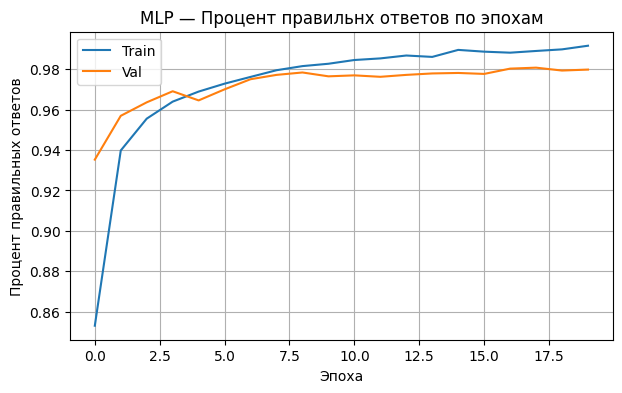

In [ ]:
mlp = nn.Sequential( # контейнер который складывает слои в очередь
    # полносвязный слой, на вход 28х28=784, на выходе 256 нейронов
    # ReLU добавляет нелинейность
    # случайно отключает 30% нейронов в каждом батче
    nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128,  10)
).to(device)

print("Архитектура MLP (многослойный перцептрон):")
print(mlp)

# создаётся датасет из обучающих данных в режиме flat
# shuffle - перемешиваются данные перед каждой эпохой
train_loader = DataLoader(DigitDataset(X_train, y_train, mode='flat'), batch_size=128, shuffle=True)
# датасет для валидации
val_loader   = DataLoader(DigitDataset(X_val,   y_val,   mode='flat'), batch_size=128)

# измеряет насколько плохо модель предсказывает (берёт 10 выходных чисел модели, применяет Softmax
#  (переводит в вероятности от 0 до 1 которые в сумме дают 1),
#  потом считает насколько вероятность правильного класса далека от 1.0.
#  Чем ближе к нулю — тем лучше модель.)
criterion = nn.CrossEntropyLoss()

# оптимизатор — алгоритм который обновляет веса
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)


# ЦИКЛ ОБУЧЕНИЯ
train_accs, val_accs = [], []

for epoch in range(1, 21):
    _, tr_acc = train_epoch(mlp, train_loader, criterion, optimizer)
    _, vl_acc = evaluate(mlp, val_loader, criterion)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    print(f"Эпоха {epoch:02d} | точность на обучении: {tr_acc:.4f} | точность на валидации: {vl_acc:.4f}")

print(f"\nMLP итоговая точность на валидации: {val_accs[-1]*100:.2f}%")
plot_history(train_accs, val_accs, 'MLP')

Свёрточная нейронная сеть

Архитектура CNN:
Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=128, out_features=10, bias=True)
)
Эпоха 01 | точность на обучении: 0.8779 | точность на валидации: 0.9726
Эпоха 02 | точность на обучении: 0.9699 | точность на валидации: 0.9788
Эпоха 03 | точность на обучении: 0.9781 | точность на валидации: 0.9812
Эпоха 04 | точность на обучении: 0.9828 | точность на валидации: 0.9838
Эпоха 05 | точность на обучении: 0.9863 | точность на валидации: 0.9862
Эпоха 06 | точность на обучении: 0.9871 | точность на валида

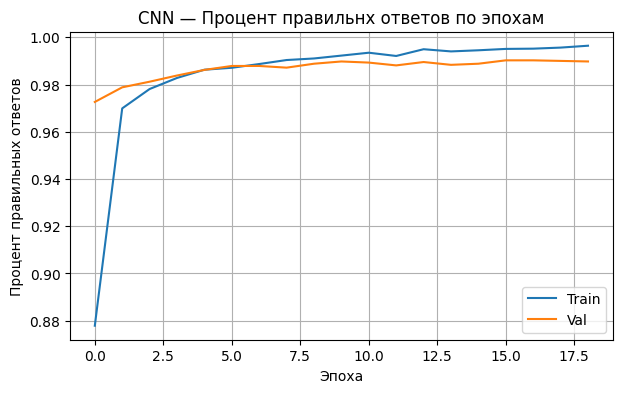

In [ ]:
cnn = nn.Sequential(
    # свёрточный блок 1
    nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),        # 28×28 - 14×14

    # свёрточный блок 2
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),        # 14×14 - 7×7

    # классификатор
    nn.Flatten(),           # 64×7×7 = 3136
    nn.Linear(3136, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 10)
).to(device)

print("Архитектура CNN:")
print(cnn)


train_loader_cnn = DataLoader(DigitDataset(X_train, y_train, mode='image'), batch_size=128, shuffle=True)
val_loader_cnn   = DataLoader(DigitDataset(X_val,   y_val,   mode='image'), batch_size=128)
test_loader_cnn  = DataLoader(DigitDataset(X_test,            mode='image'), batch_size=128)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

train_accs, val_accs = [], []

for epoch in range(1, 20):
    _, tr_acc = train_epoch(cnn, train_loader_cnn, criterion, optimizer)
    _, vl_acc = evaluate(cnn, val_loader_cnn, criterion)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    print(f"Эпоха {epoch:02d} | точность на обучении: {tr_acc:.4f} | точность на валидации: {vl_acc:.4f}")

print(f"\nCNN и итоговая точность на валидации: {val_accs[-1]*100:.2f}%")
plot_history(train_accs, val_accs, 'CNN')

Модель     Точность на валидации
MLP                 97.98%
CNN                 98.98%


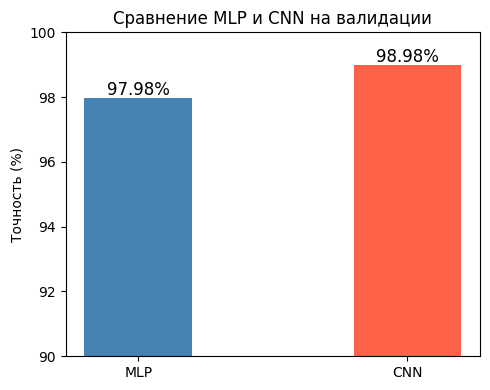

In [ ]:
# точность на валидации
criterion = nn.CrossEntropyLoss()

_, mlp_acc = evaluate(mlp, val_loader,     criterion)
_, cnn_acc = evaluate(cnn, val_loader_cnn, criterion)

print(f"{'Модель':<10} {'Точность на валидации':>15}")
print(f"{'MLP':<10} {mlp_acc*100:>14.2f}%")
print(f"{'CNN':<10} {cnn_acc*100:>14.2f}%")

models = ['MLP', 'CNN']
accs   = [mlp_acc * 100, cnn_acc * 100]

plt.figure(figsize=(5, 4))
bars = plt.bar(models, accs, color=['steelblue', 'tomato'], width=0.4)
plt.ylim(90, 100)
plt.ylabel('Точность (%)')
plt.title('Сравнение MLP и CNN на валидации')

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

Загрузка фото:


Saving 0.png to 0 (1).png
Saving 1.png to 1 (1).png
Saving 2.png to 2 (1).png
Saving 3.png to 3 (1).png
Saving 4.png to 4 (1).png
Saving 5.png to 5 (1).png
Saving 6.png to 6 (1).png
Saving 7.png to 7 (1).png
Saving 8.png to 8 (1).png
Saving 9.png to 9 (1).png


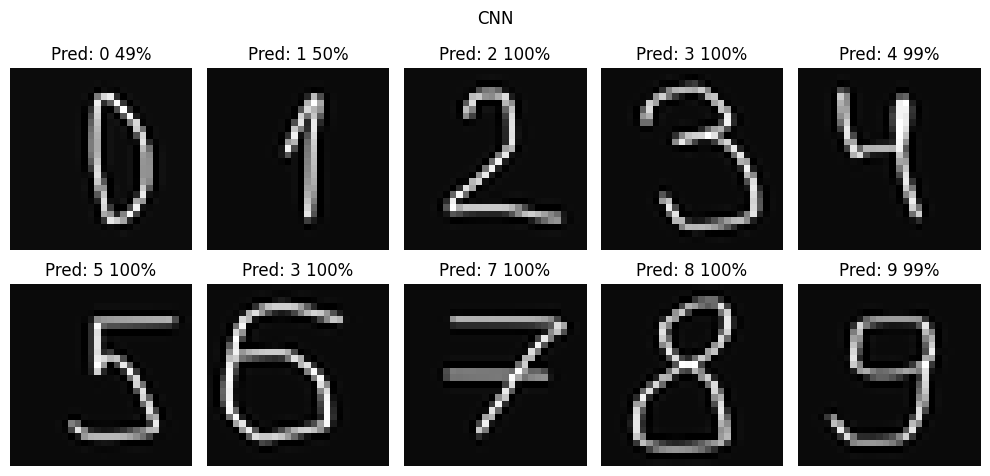

In [ ]:
from PIL import Image, ImageOps
from google.colab import files
import io

print("Загрузка фото:")
uploaded = files.upload()

def prepare_photo(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('L')  # grayscale
    img = ImageOps.invert(img)                             # белый фон на чёрный
    img = img.resize((28, 28), Image.LANCZOS)              # resize 28×28
    arr = np.array(img, dtype='float32') / 255.0

    # для инверсии цвета цифры
    if arr.mean() > 0.5:
        arr = 1.0 - arr

    return arr

my_imgs, my_names = [], []
for fname, fdata in uploaded.items():
    my_imgs.append(prepare_photo(fdata))
    my_names.append(fname)

my_imgs = np.array(my_imgs)

# предсказание
cnn.eval()
tensor = torch.tensor(my_imgs).unsqueeze(1).to(device)
with torch.no_grad():
    probs = torch.softmax(cnn(tensor), dim=1).cpu().numpy()
preds = probs.argmax(axis=1)
confs = probs.max(axis=1)

# визуализация
n    = len(my_imgs)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
axes = np.array(axes).flatten()

for i in range(len(axes)):
    if i < n:
        axes[i].imshow(my_imgs[i], cmap='gray')
        axes[i].set_title(f"Pred: {preds[i]} {confs[i]*100:.0f}%")
    axes[i].axis('off')

plt.suptitle('CNN')
plt.tight_layout()
plt.show()

ЛАБ 3

---



In [ ]:
# для готовых функций-трансформаций
from torchvision import transforms
import torchvision.transforms.functional as TF

# аугментация — трансформации которые применяются к изображению
augment_transform = transforms.Compose([   # конвейер, применяет к списку трансформации одну за одной
    transforms.RandomRotation(degrees=45), # поворот от -15 до +15 градусов
    transforms.RandomAffine(degrees=0, translate=(0.3, 0.3)),  # Аффинное преобразование - сдвиг до 10% ширины и высоты без поворота
    transforms.RandomAffine(degrees=0, shear=20),    # наклон на 10 (как руксив)
    transforms.GaussianBlur(kernel_size=3, sigma=(0.2, 1.0)),  # размытие по Гауссу (окно размытия 3 на 3 пикселя)
])

# датасет с аугментацией (принимает тензор 1×28×28, применяет трансформации)
class AugmentedDigitDataset(Dataset):
    def __init__(self, X, y=None, augment=False):
        self.X = X  # все изображения (numpy массив)
        self.y = y  # метки (правильные ответы)
        self.augment = augment # флаг: применять аугментацию или нет

# Возвращает количество изображений
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
      # перевод из вектора 784 в тензор 1, 28, 28 (один канал, 28×28 пикселей)
        img = torch.tensor(self.X[idx]).reshape(1, 28, 28)

        if self.augment:
            # Если флаг augment=True — применяем весь конвейер трансформаций к изображению.
            img = augment_transform(img)

# Если есть метки (обучение/валидация) — возвращаем пару (картинка, ответ). Если меток нет (тестовые данные) — только картинку.
        if self.y is not None:
            return img, torch.tensor(self.y[idx])
        return img

## тест старой модели на аугментированных данных
# создаём аугментированный валидационный загрузчик
val_loader_aug = DataLoader(
    #  каждое изображение при выдаче будет случайно искажаться
    AugmentedDigitDataset(X_val, y_val, augment=True),
    batch_size=128 # по 128 картинок за раз
)

# тест старой (необученную на аугментации) CNN на аугментированных данных
criterion = nn.CrossEntropyLoss()
_, cnn_acc_on_aug = evaluate(cnn, val_loader_aug, criterion)
print(f"CNN (без аугм. обучения) на аугм. данных: {cnn_acc_on_aug*100:.2f}%")

# Для сравнения — на обычных данных
# _ — потери нас не интересуют, берём только точность
_, cnn_acc_clean = evaluate(cnn, val_loader_cnn, criterion)
print(f"CNN (без аугм. обучения) на чистых данных: {cnn_acc_clean*100:.2f}%")

CNN (без аугм. обучения) на аугм. данных: 22.17%
CNN (без аугм. обучения) на чистых данных: 98.98%



Файл                   Оригинал    Аугм.среднее  Уверенность
0 (1).png                     0               6        35.9%
1 (1).png                     1               7        29.6%
2 (1).png                     2               2        52.0%
3 (1).png                     3               3        32.9%
4 (1).png                     4               1        31.7%
5 (1).png                     5               2        33.7%
6 (1).png                     3               5        20.6%
7 (1).png                     7               5        27.0%
8 (1).png                     8               6        26.9%
9 (1).png                     9               1        27.4%


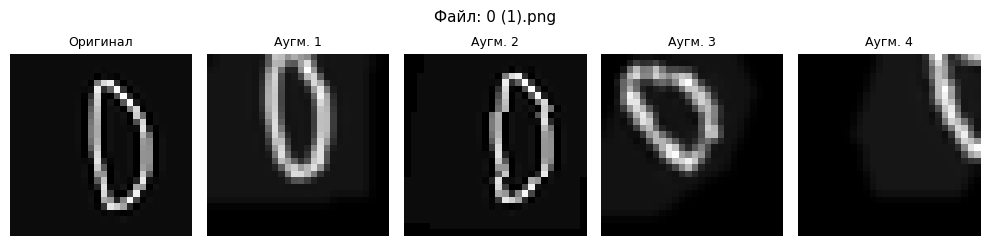

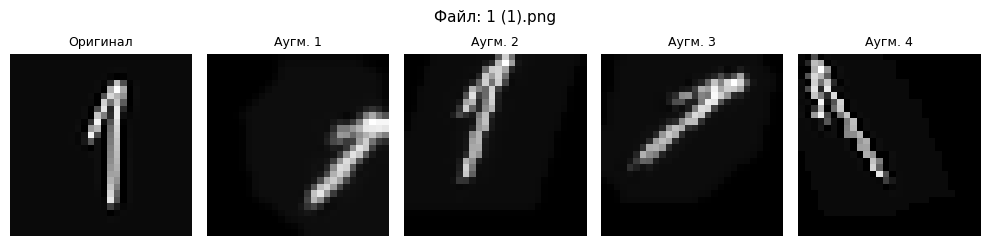

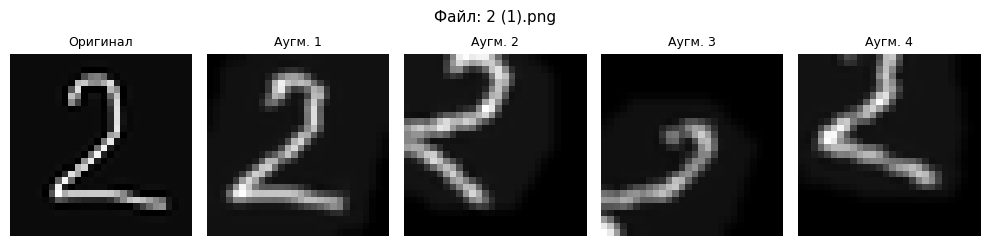

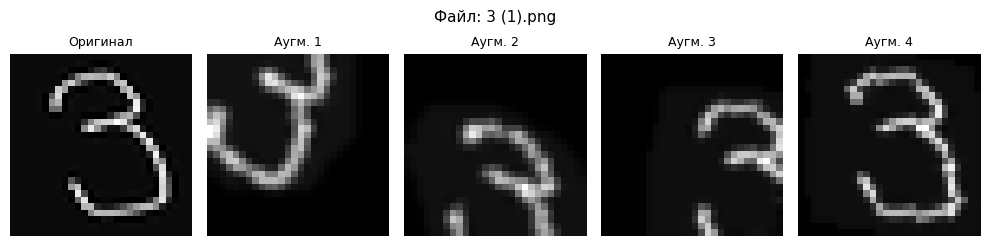

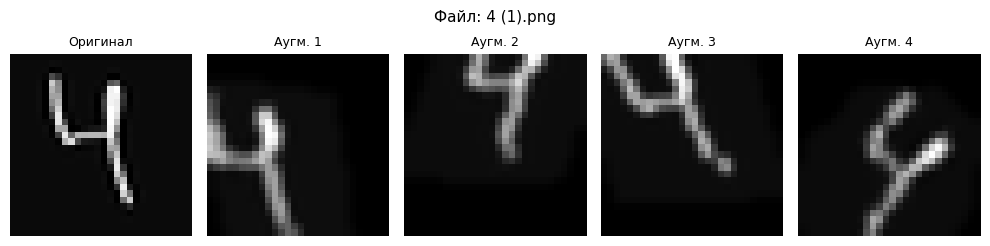

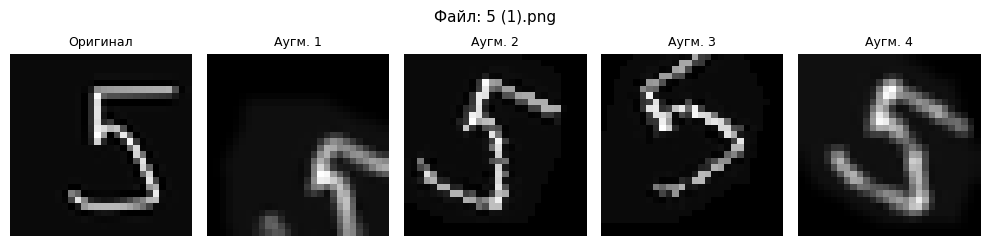

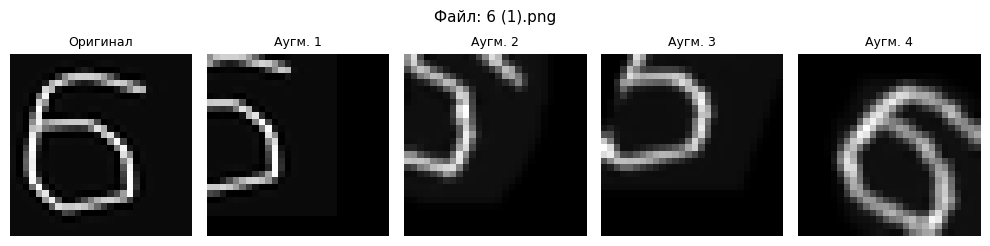

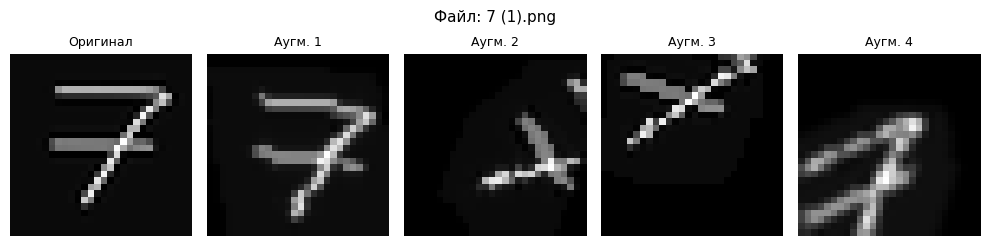

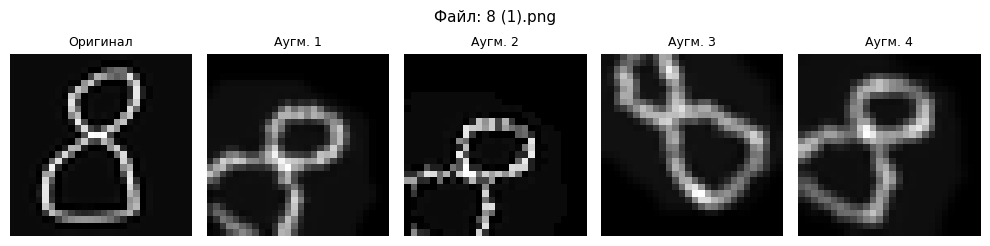

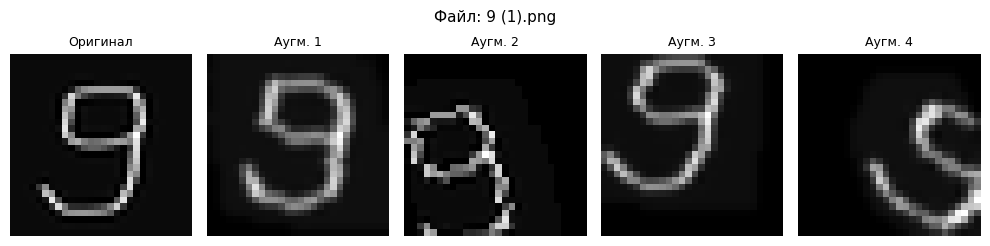

In [ ]:
# тест на моих фото

def test_my_images_augmented(my_imgs, my_names, model, n_augments=5):
    model.eval()
    print(f"\n{'Файл':<20} {'Оригинал':>10} {'Аугм.среднее':>15} {'Уверенность':>12}")

    for i, (arr, name) in enumerate(zip(my_imgs, my_names)):
        # оригинальное предсказание
        t = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            orig_pred = cnn(t).argmax(1).item()

        # предсказания на аугментированных версиях
        aug_preds = []
        for _ in range(n_augments):
            img_tensor = torch.tensor(arr).reshape(1, 28, 28)
            img_aug = augment_transform(img_tensor).unsqueeze(0).to(device)
            with torch.no_grad():
                p = torch.softmax(cnn(img_aug), dim=1)
            aug_preds.append(p.cpu().numpy())

        avg_probs = np.mean(aug_preds, axis=0)
        aug_pred  = avg_probs.argmax()
        conf      = avg_probs.max()

        print(f"{name:<20} {orig_pred:>10} {aug_pred:>15} {conf*100:>11.1f}%")

test_my_images_augmented(my_imgs, my_names, cnn)


# визуализация своих фото до и после аугментации
if len(my_imgs) > 0:
    n_augments = 4  # версий всего

    for arr, name in zip(my_imgs, my_names):
        fig, axes = plt.subplots(1, n_augments + 1, figsize=((n_augments + 1) * 2, 2.5))

        # первая картинка — оригинал
        axes[0].imshow(arr, cmap='gray')
        axes[0].set_title('Оригинал', fontsize=9)
        axes[0].axis('off')

        # остальные — аугментированные версии
        for i in range(n_augments):
            img_tensor = torch.tensor(arr).reshape(1, 28, 28)
            img_aug = augment_transform(img_tensor).squeeze().numpy()
            axes[i + 1].imshow(img_aug, cmap='gray')
            axes[i + 1].set_title(f'Аугм. {i+1}', fontsize=9)
            axes[i + 1].axis('off')

        plt.suptitle(f'Файл: {name}', fontsize=11)
        plt.tight_layout()
        plt.show()

Пример #0


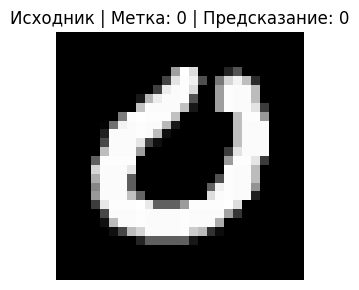

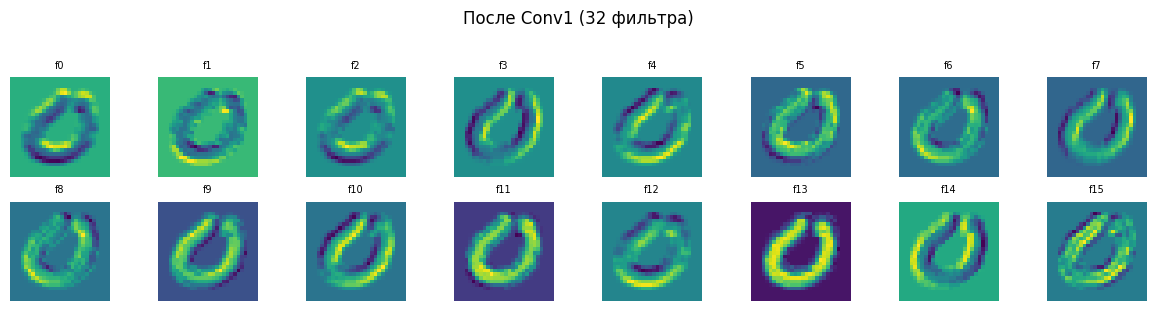

  Размер: (32, 28, 28)


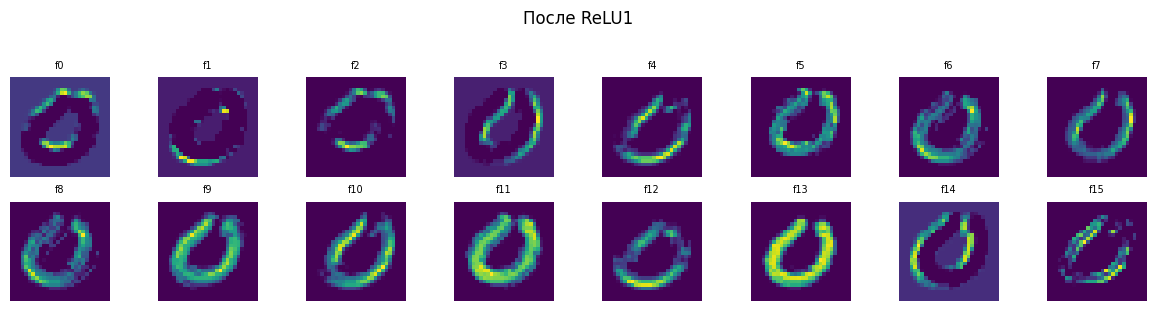

  Размер: (32, 28, 28)


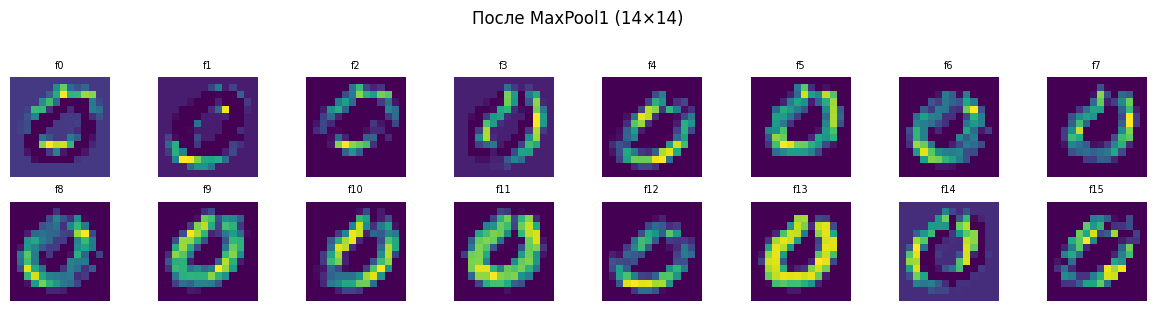

  Размер: (32, 14, 14)


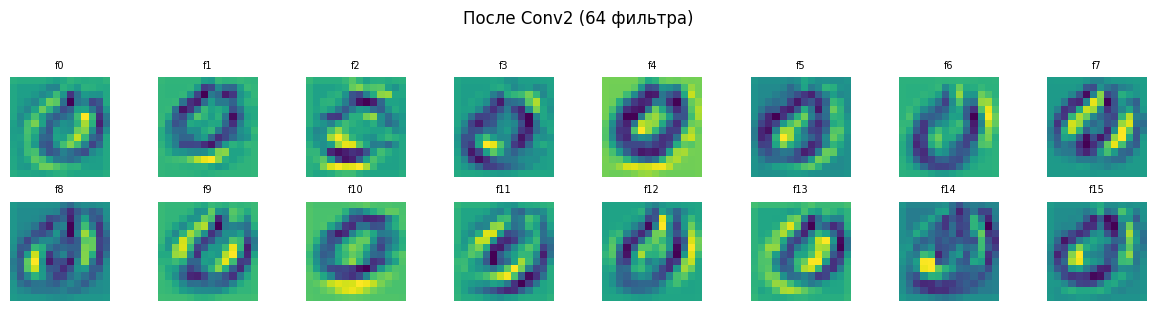

  Размер: (64, 14, 14)


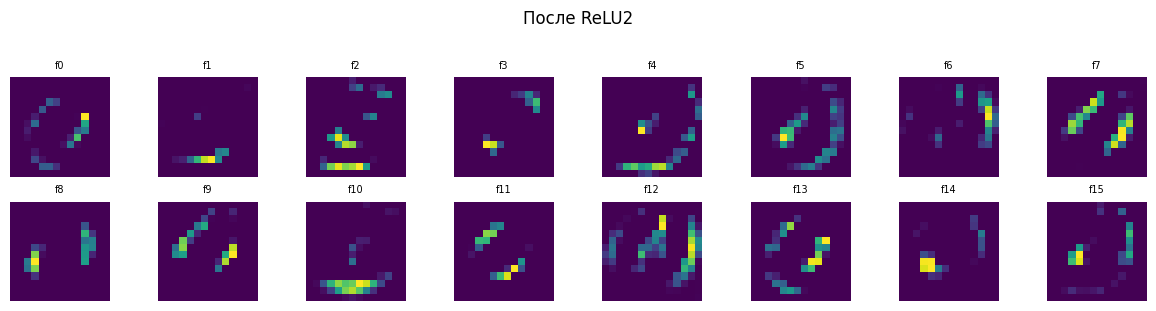

  Размер: (64, 14, 14)


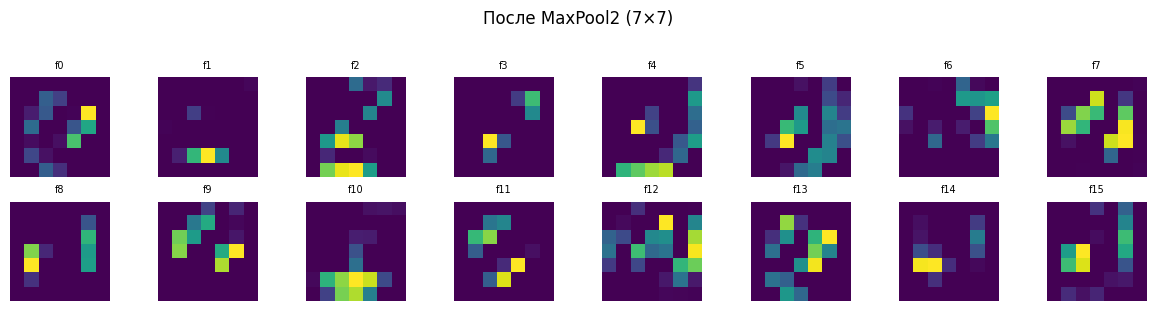

  Размер: (64, 7, 7)
Пример #5


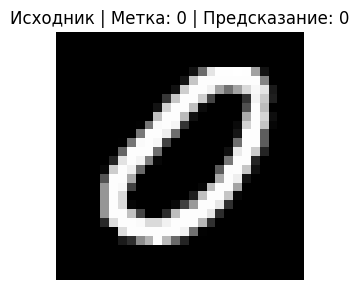

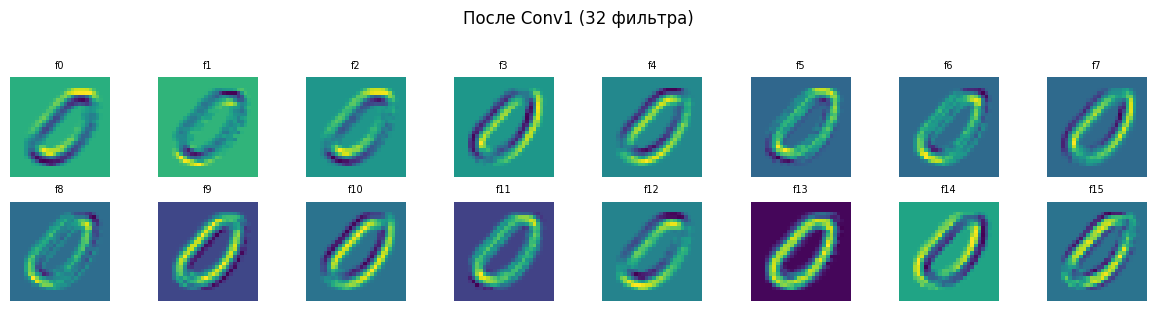

  Размер: (32, 28, 28)


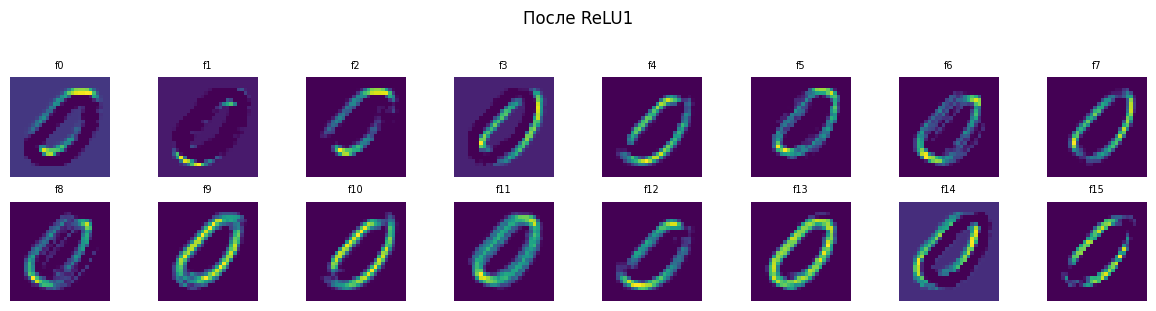

  Размер: (32, 28, 28)


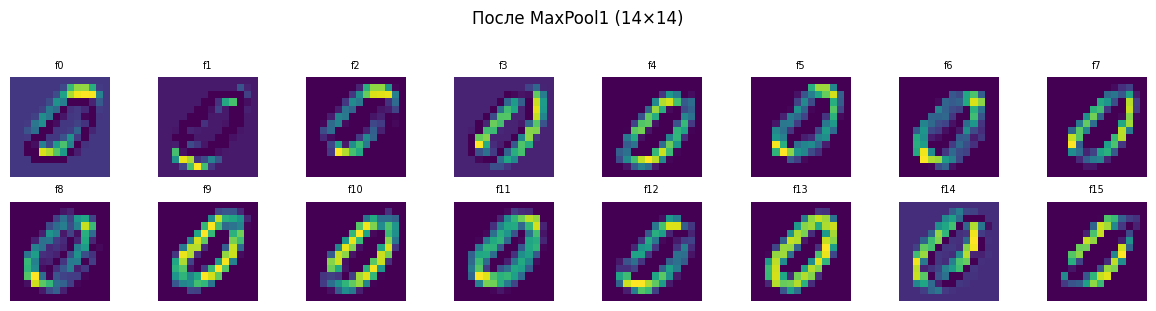

  Размер: (32, 14, 14)


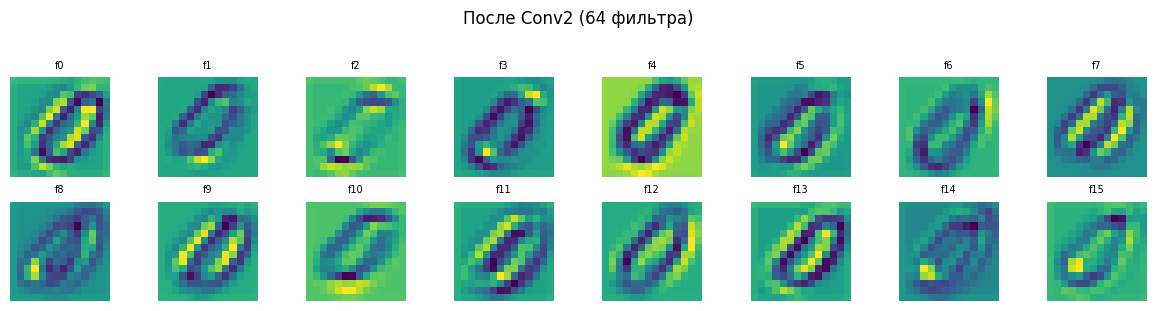

  Размер: (64, 14, 14)


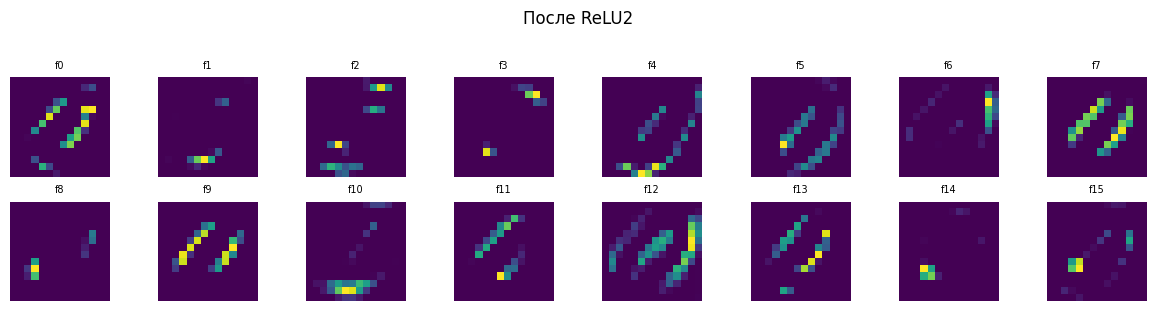

  Размер: (64, 14, 14)


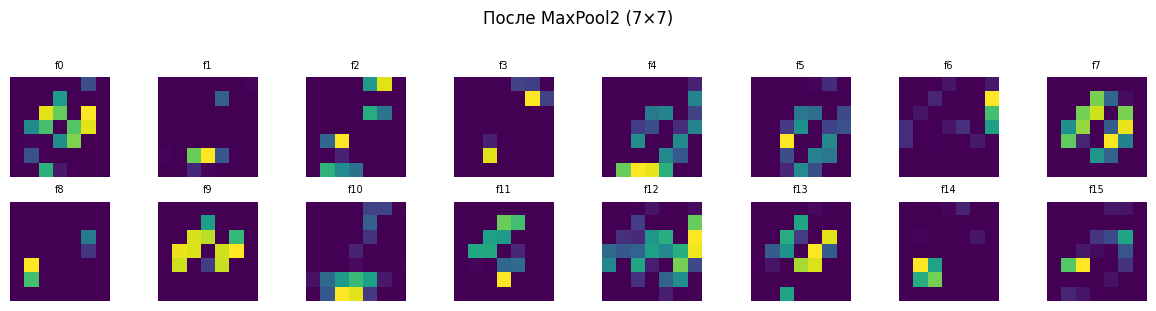

  Размер: (64, 7, 7)
Пример #10


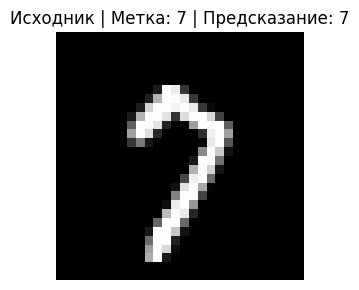

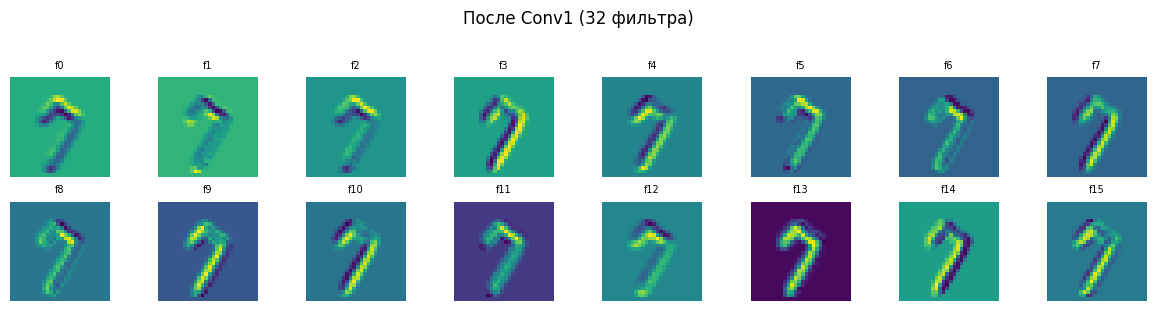

  Размер: (32, 28, 28)


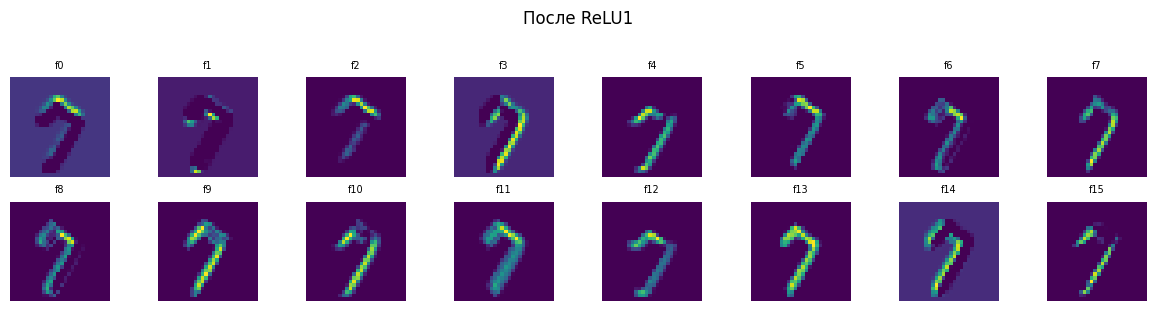

  Размер: (32, 28, 28)


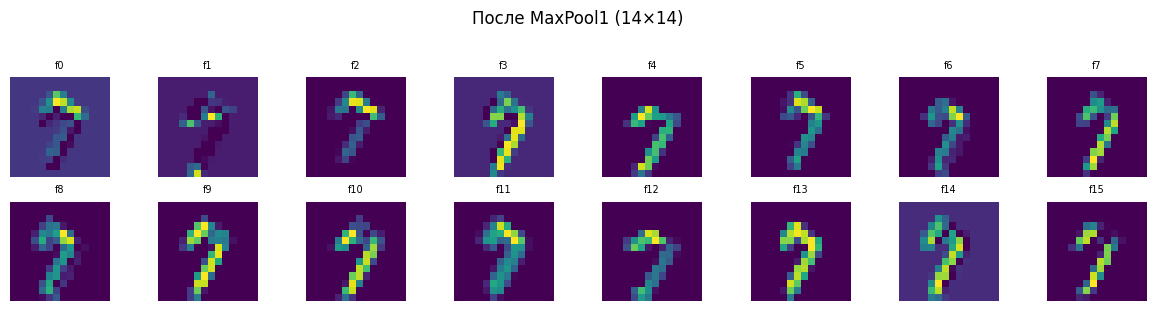

  Размер: (32, 14, 14)


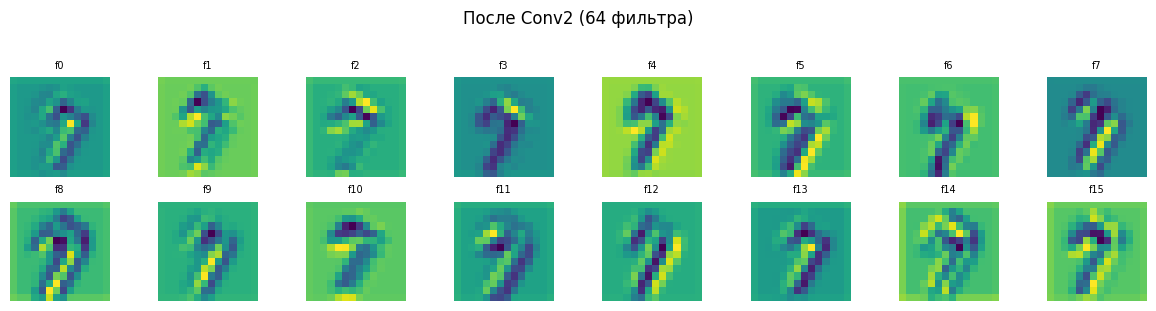

  Размер: (64, 14, 14)


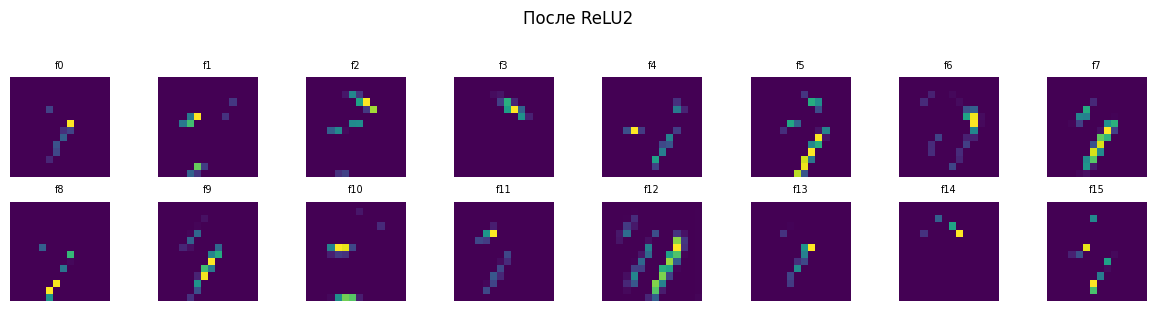

  Размер: (64, 14, 14)


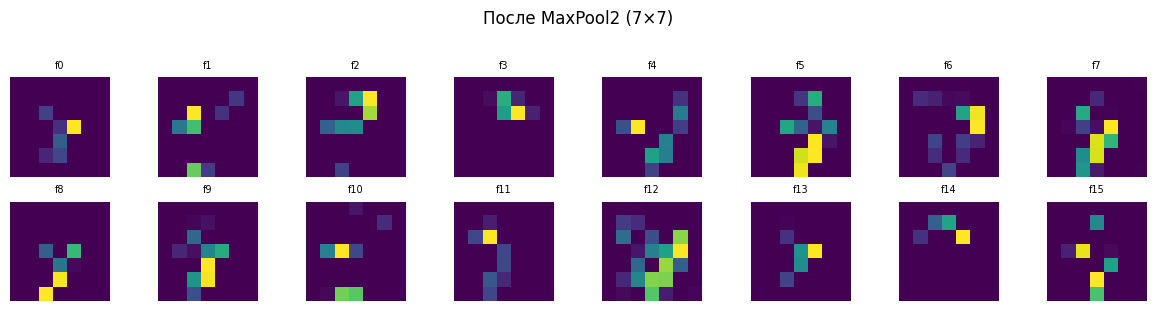

  Размер: (64, 7, 7)


In [ ]:
# промежуточные выходы (feature maps карту активаций) из обученной CNN
# feature map показывает где на картинке этот признак нашёлся


# model — обученная сеть
# X_sample — массив изображений из которого берём один пример
# y_sample — правильные ответы, None если их нет
# img_idx — номер картинки которую хотим посмотреть, по умолчанию первая

def show_feature_maps(model, X_sample, y_sample=None, img_idx=0):
    # Переключает модель в режим оценки (Отключает Dropout)
    model.eval()

    # берём одно изображение
    if X_sample.ndim == 2:     # если 2 измерения
      #  1 картинка в батче, 1 канал (оттенки серого), 28×28 пикселей
        img = torch.tensor(X_sample[img_idx]).reshape(1, 1, 28, 28).to(device)
    else:
      # добавляем размерность батча через unsqueeze(0)
        img = torch.tensor(X_sample[img_idx]).unsqueeze(0).to(device)

    label = y_sample[img_idx] if y_sample is not None else "?"

    # Hooks — перехватчики которые сохраняют выход каждого слоя
    activations = {}

    def make_hook(name):
        def hook(module, input, output):
            activations[name] = output.detach().cpu()
        return hook

    #  хуки на слои CNN
    hooks = [
        model[0].register_forward_hook(make_hook('conv1')),
        model[1].register_forward_hook(make_hook('relu1')),
        model[2].register_forward_hook(make_hook('pool1')),
        model[3].register_forward_hook(make_hook('conv2')),
        model[4].register_forward_hook(make_hook('relu2')),
        model[5].register_forward_hook(make_hook('pool2')),
    ]

# Прямой проход через сеть
    with torch.no_grad():
        out = model(img)
        pred = out.argmax(1).item()

    # Убираем хуки после использования
    for h in hooks:
        h.remove()

    fig, axes = plt.subplots(1, 1, figsize=(3, 3))
    axes.imshow(img.squeeze().cpu(), cmap='gray')
    axes.set_title(f'Исходник | Метка: {label} | Предсказание: {pred}')
    axes.axis('off')
    plt.tight_layout()
    plt.show()

    # Feature maps для каждого этапа
    stages = [
        ('После Conv1 (32 фильтра)',  'conv1'),
        ('После ReLU1',               'relu1'),
        ('После MaxPool1 (14×14)',     'pool1'),
        ('После Conv2 (64 фильтра)',   'conv2'),
        ('После ReLU2',               'relu2'),
        ('После MaxPool2 (7×7)',       'pool2'),
    ]

    for title, key in stages:
        fmap = activations[key].squeeze(0)  # Берём сохранённый выход слоя из словаря. .squeeze(0) — убираем размерность батча, остается(C, H, W)
        n_filters = min(fmap.shape[0], 16)  # показываем не более 16 фильтров

        cols = 8
        rows = (n_filters + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
        axes = np.array(axes).flatten()

        for j in range(len(axes)):
            if j < n_filters:
                axes[j].imshow(fmap[j], cmap='viridis')
                axes[j].set_title(f'f{j}', fontsize=7)
            axes[j].axis('off')

        plt.suptitle(title, fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
        print(f"  Размер: {tuple(fmap.shape)}")

# Запуск — берём несколько примеров из валидации
for idx in [0, 5, 10]:
    print(f"Пример #{idx}")
    show_feature_maps(cnn, X_val, y_val, img_idx=idx)

Обучение CNN на аугментированных данных:
Эпоха 01 | обучение: 0.3721 | валидация: 0.6110
Эпоха 02 | обучение: 0.6333 | валидация: 0.7529
Эпоха 03 | обучение: 0.7076 | валидация: 0.8138
Эпоха 04 | обучение: 0.7500 | валидация: 0.8443
Эпоха 05 | обучение: 0.7805 | валидация: 0.8540
Эпоха 06 | обучение: 0.8048 | валидация: 0.8764
Эпоха 07 | обучение: 0.8198 | валидация: 0.8726
Эпоха 08 | обучение: 0.8317 | валидация: 0.8855
Эпоха 09 | обучение: 0.8401 | валидация: 0.8981

CNN (с аугментацией) итоговая точность: 89.81%


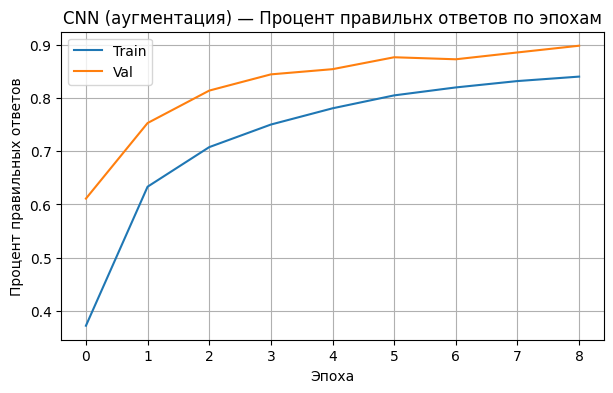

In [ ]:
# создаём новую CNN с той же архитектурой
cnn_aug = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(), # Разворачивает трёхмерный тензор в одномерный вектор
    nn.Linear(3136, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 10)
).to(device)

# аугментированный train loader
train_loader_aug = DataLoader(
    AugmentedDigitDataset(X_train, y_train, augment=True),
    batch_size=128, shuffle=True
)

criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(cnn_aug.parameters(), lr=1e-3)

train_accs_aug, val_accs_aug = [], []

print("Обучение CNN на аугментированных данных:")
for epoch in range(1, 10):
    _, tr_acc = train_epoch(cnn_aug, train_loader_aug, criterion, optimizer)
    _, vl_acc = evaluate(cnn_aug, val_loader_aug, criterion)  # тест тоже на аугм.
    train_accs_aug.append(tr_acc)
    val_accs_aug.append(vl_acc)
    print(f"Эпоха {epoch:02d} | обучение: {tr_acc:.4f} | валидация: {vl_acc:.4f}")

print(f"\nCNN (с аугментацией) итоговая точность: {val_accs_aug[-1]*100:.2f}%")
plot_history(train_accs_aug, val_accs_aug, 'CNN (аугментация)')


Модель                      Чистые данные    Аугм. данные
CNN (без аугм.)                    98.98%          25.33%
CNN (с аугм.)                       95.71%          89.38%


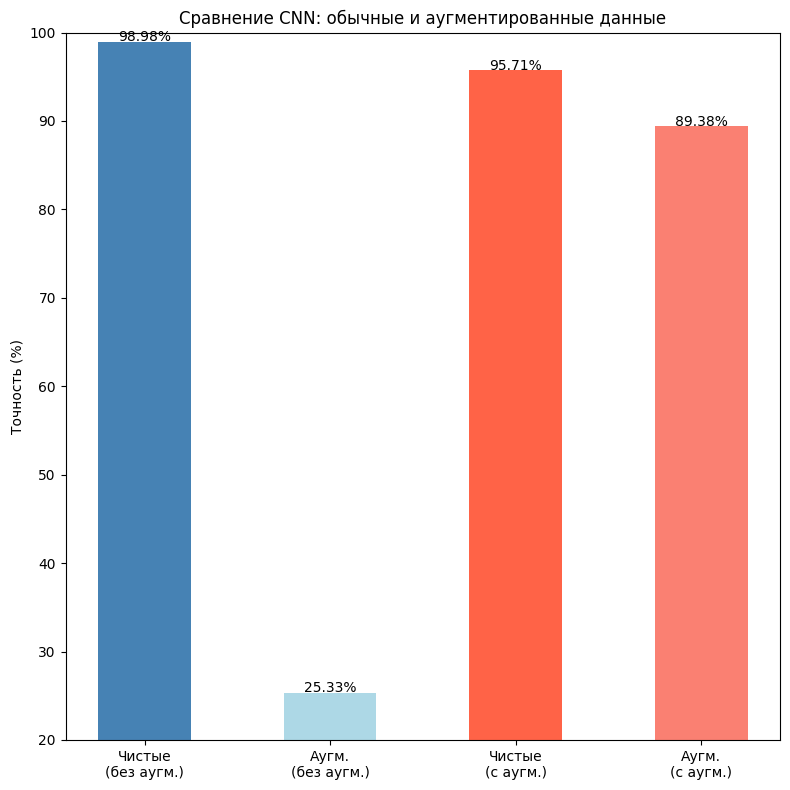

In [ ]:
# Сравниваем все результаты
_, acc_old_clean = evaluate(cnn,     val_loader_cnn, criterion)
_, acc_old_aug   = evaluate(cnn,     val_loader_aug, criterion)
_, acc_new_clean = evaluate(cnn_aug, val_loader_cnn, criterion)
_, acc_new_aug   = evaluate(cnn_aug, val_loader_aug, criterion)

print(f"\n{'Модель':<25} {'Чистые данные':>15} {'Аугм. данные':>15}")
print(f"{'CNN (без аугм.)':<25} {acc_old_clean*100:>14.2f}% {acc_old_aug*100:>14.2f}%")
print(f"{'CNN (с аугм.)':<25}  {acc_new_clean*100:>14.2f}% {acc_new_aug*100:>14.2f}%")

# Столбчатая диаграмма
labels  = ['Чистые\n(без аугм.)', 'Аугм.\n(без аугм.)', 'Чистые\n(с аугм.)', 'Аугм.\n(с аугм.)']
values  = [acc_old_clean*100, acc_old_aug*100, acc_new_clean*100, acc_new_aug*100]
colors  = ['steelblue', 'lightblue', 'tomato', 'salmon']

plt.figure(figsize=(8, 8))
bars = plt.bar(labels, values, color=colors, width=0.5)
plt.ylim(20, 100)
plt.ylabel('Точность (%)')
plt.title('Сравнение CNN: обычные и аугментированные данные')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Feature maps модели, обученной на аугментированных данных:

Пример #0


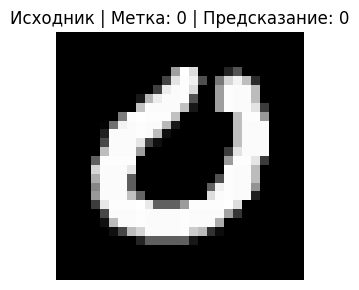

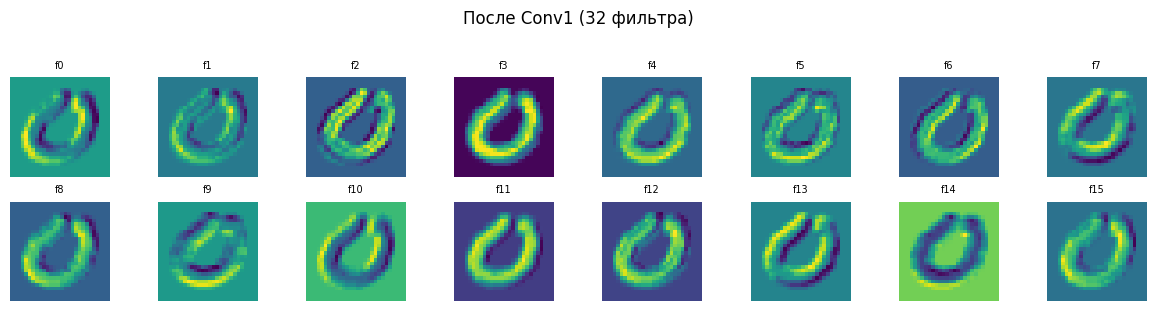

  Размер: (32, 28, 28)


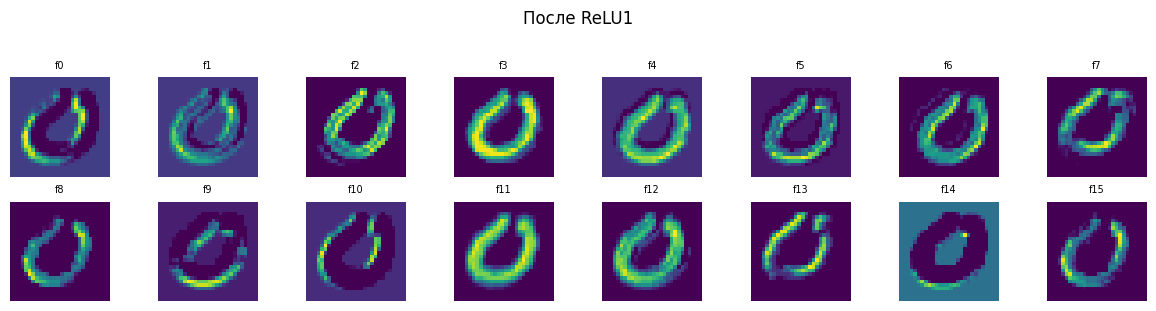

  Размер: (32, 28, 28)


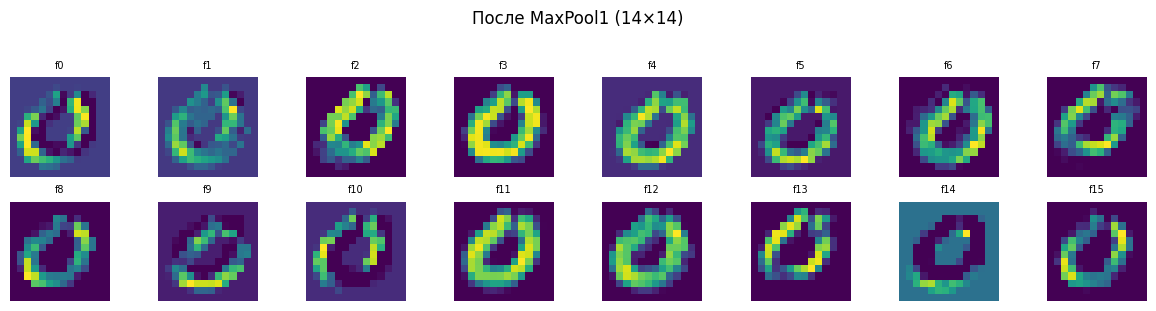

  Размер: (32, 14, 14)


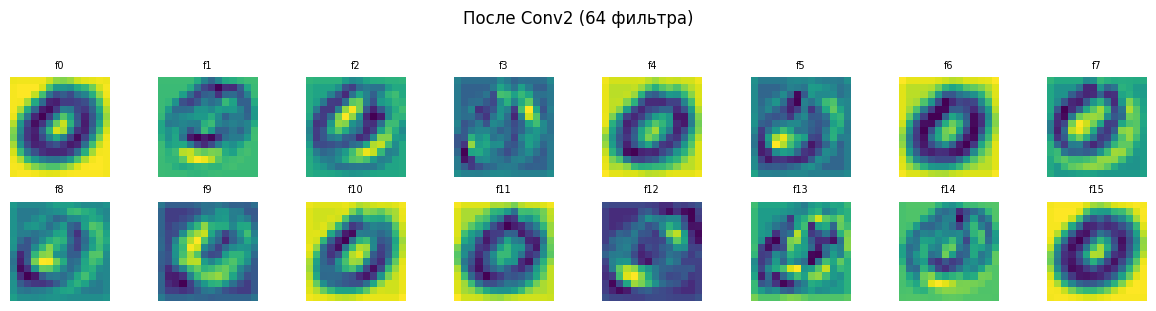

  Размер: (64, 14, 14)


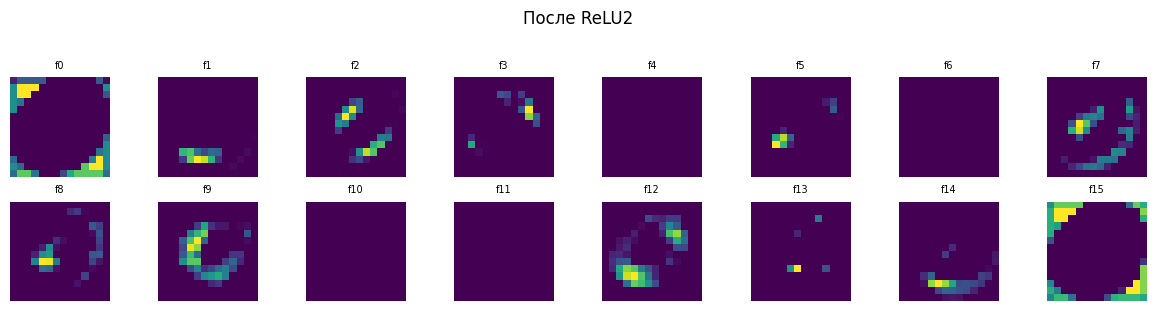

  Размер: (64, 14, 14)


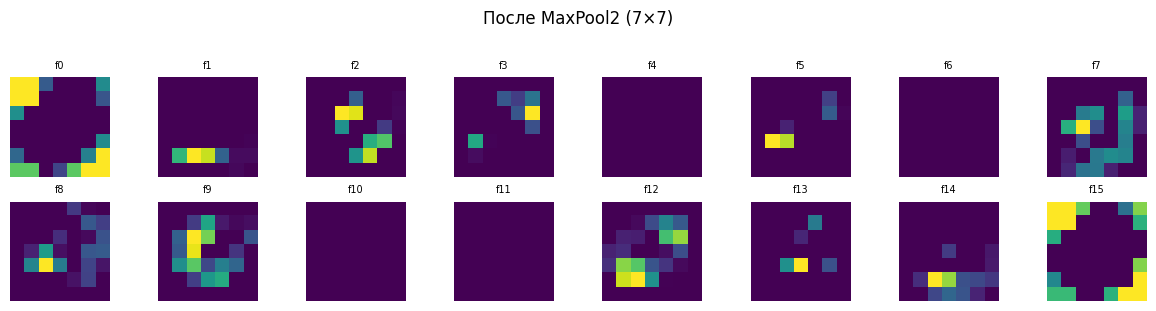

  Размер: (64, 7, 7)
Пример #5


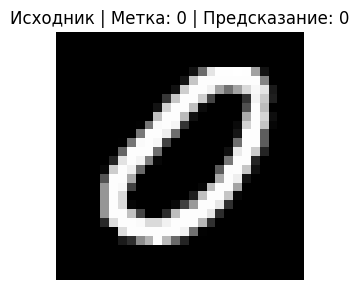

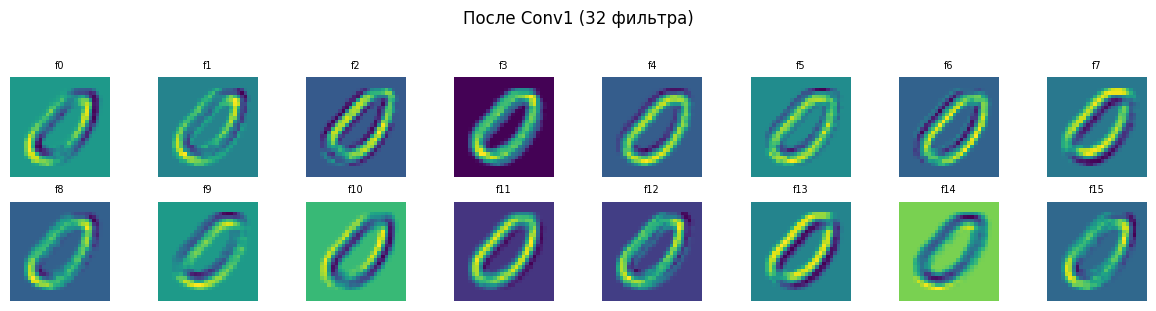

  Размер: (32, 28, 28)


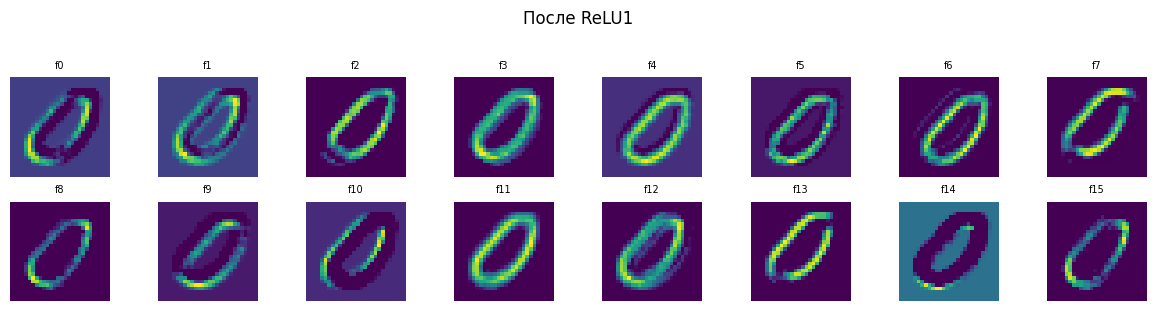

  Размер: (32, 28, 28)


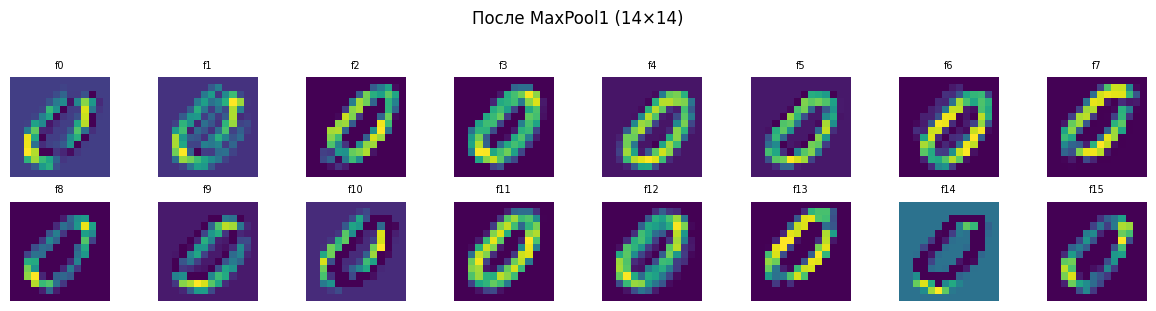

  Размер: (32, 14, 14)


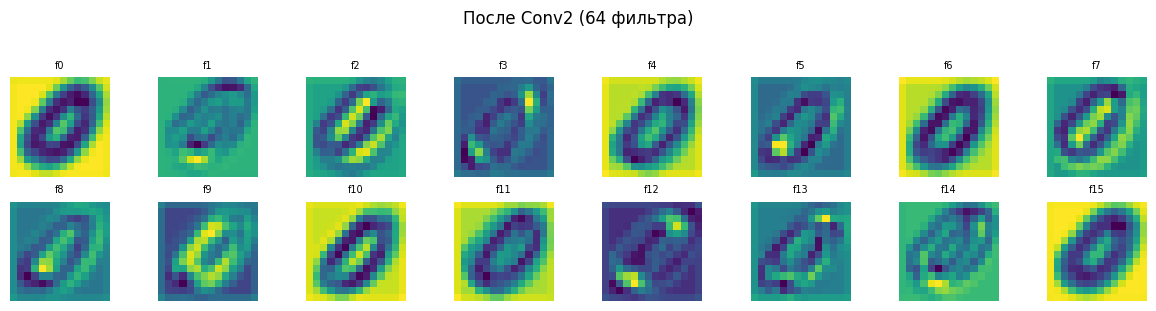

  Размер: (64, 14, 14)


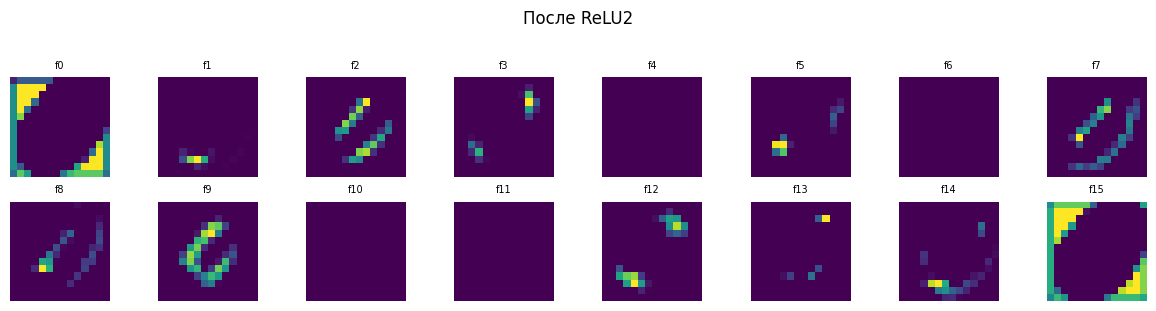

  Размер: (64, 14, 14)


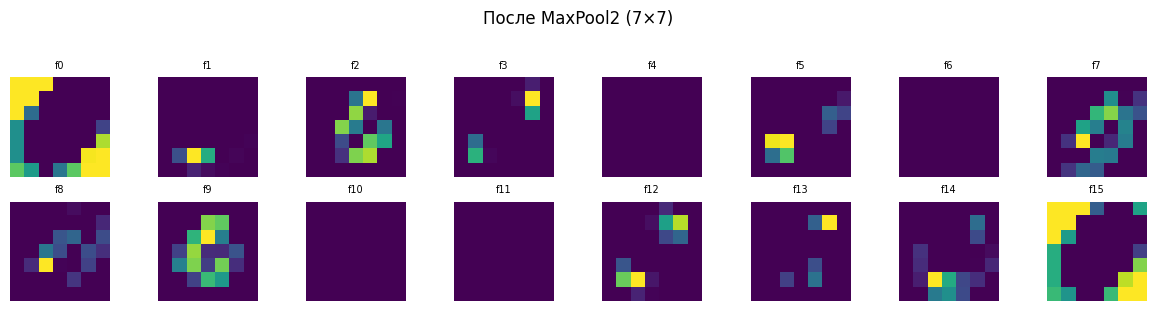

  Размер: (64, 7, 7)
Пример #10


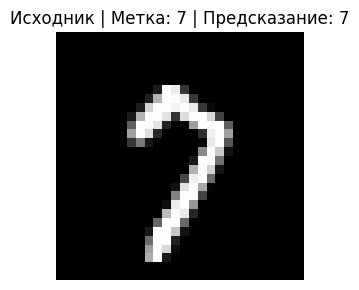

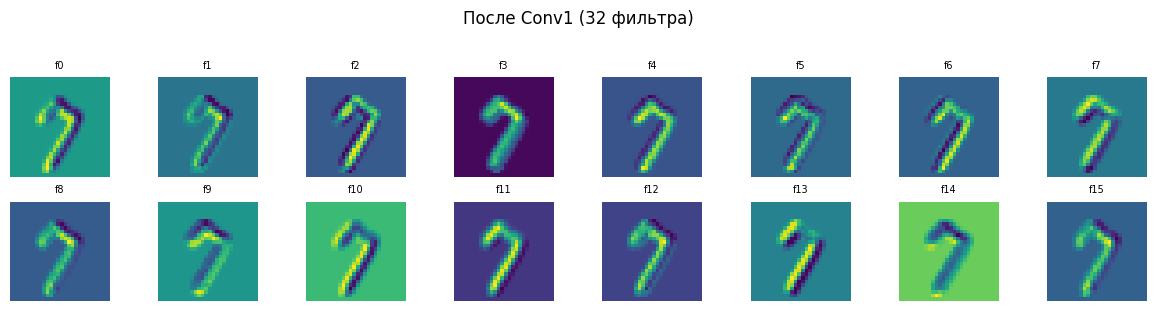

  Размер: (32, 28, 28)


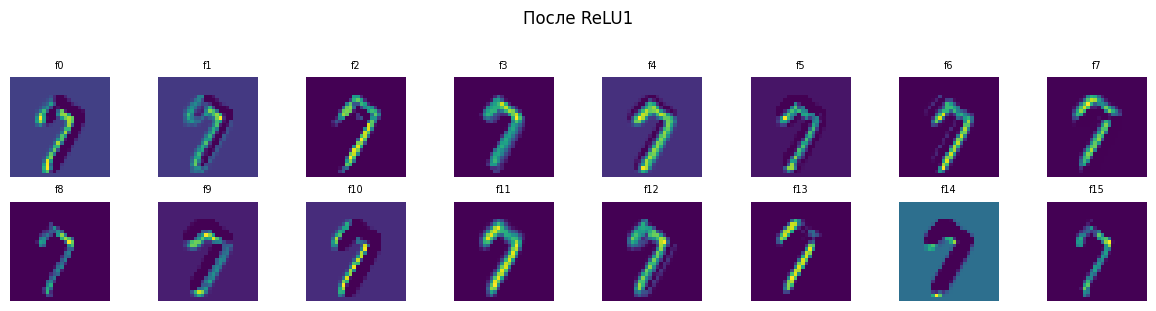

  Размер: (32, 28, 28)


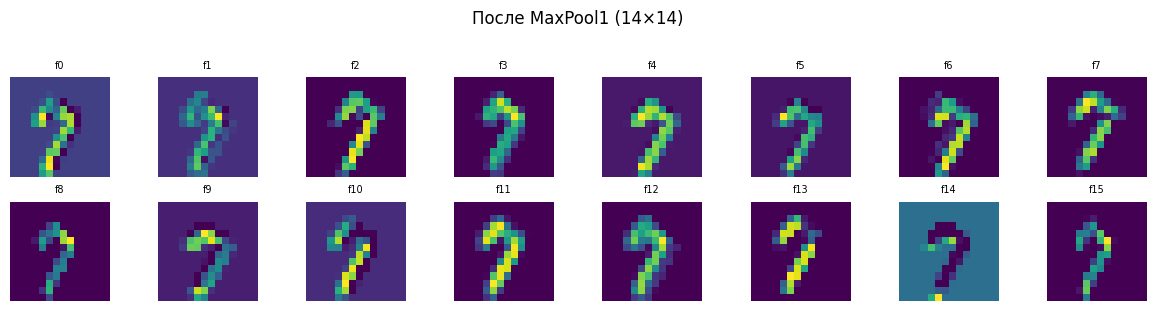

  Размер: (32, 14, 14)


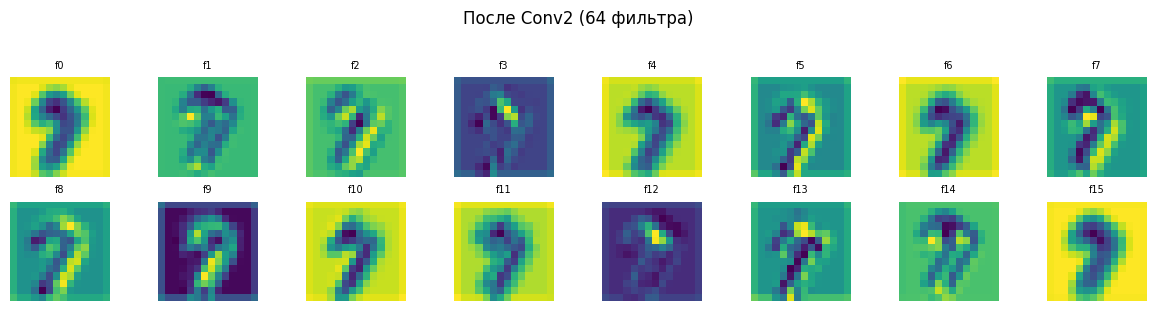

  Размер: (64, 14, 14)


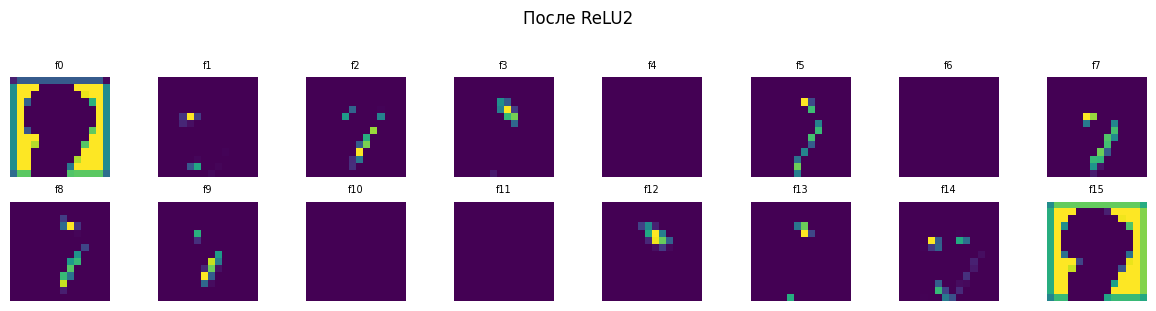

  Размер: (64, 14, 14)


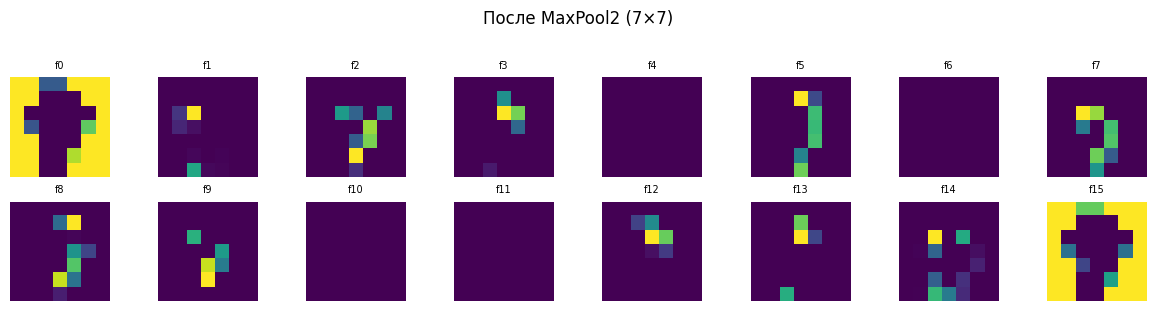

  Размер: (64, 7, 7)


In [ ]:
# То же самое, но для cnn_aug
print("Feature maps модели, обученной на аугментированных данных:\n")
for idx in [0, 5, 10]:
    print(f"Пример #{idx}")
    show_feature_maps(cnn_aug, X_val, y_val, img_idx=idx)



Тест модели с аугментацией на своих фото:



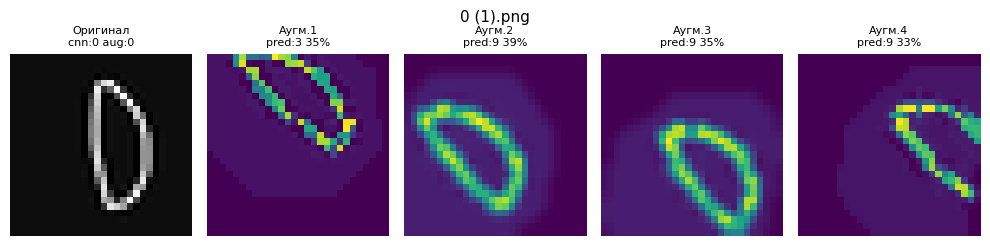

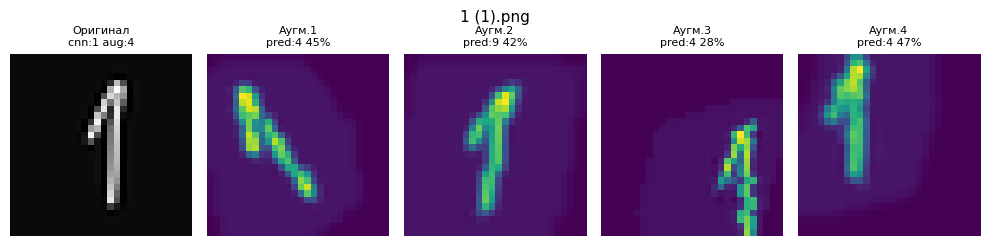

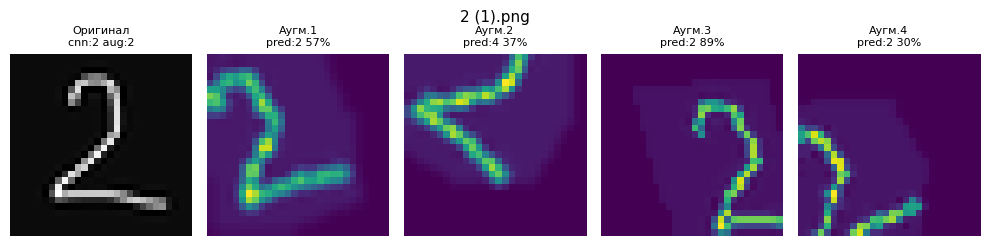

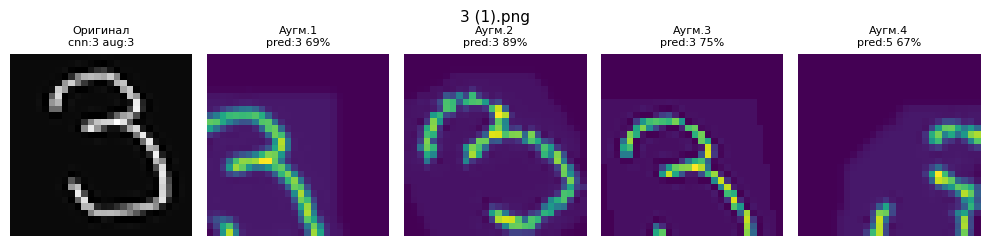

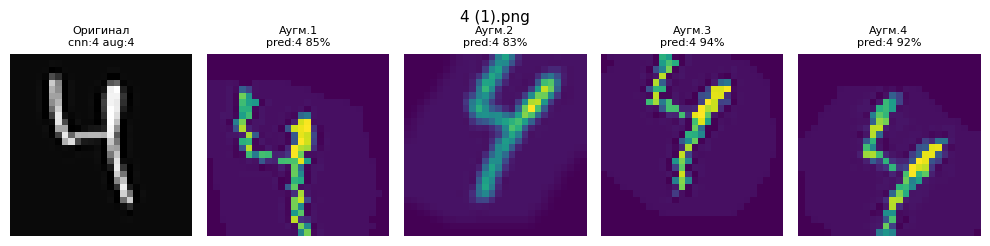

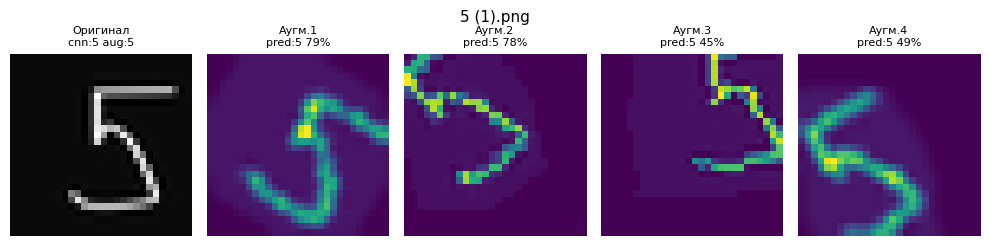

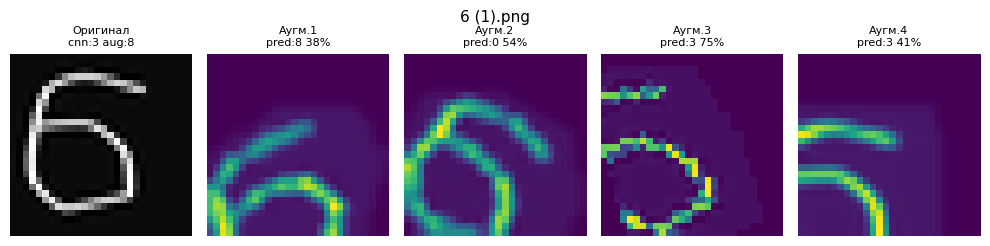

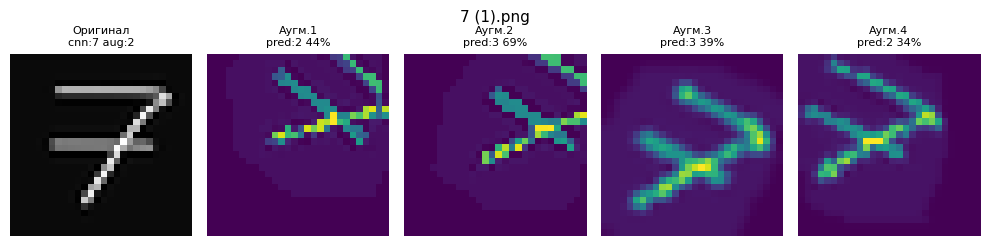

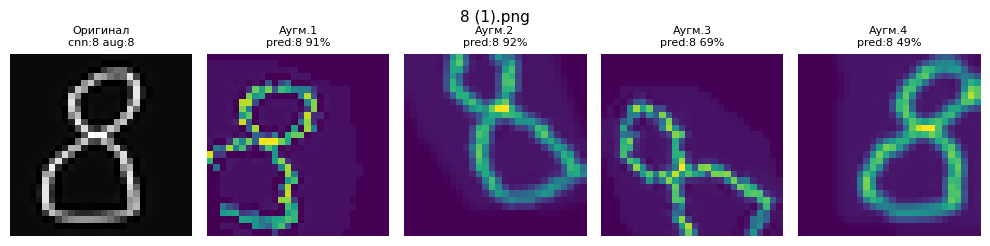

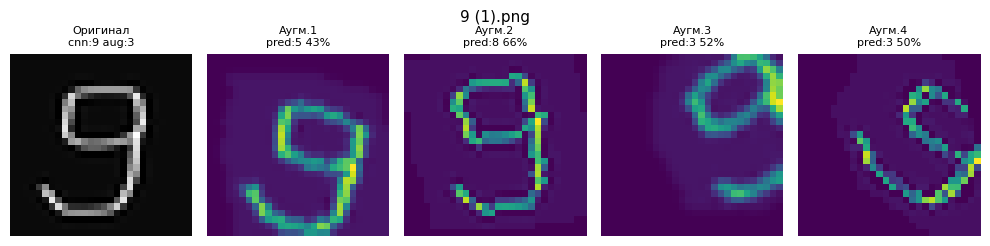

In [ ]:
# тест cnn_aug на своих фото с аугментацией
if len(my_imgs) > 0:
    print("\nТест модели с аугментацией на своих фото:\n")

    for arr, name in zip(my_imgs, my_names):
        n_augments = 4

        fig, axes = plt.subplots(1, n_augments + 1, figsize=((n_augments + 1) * 2, 2.5))

        # оригинал — предсказание старой модели (cnn)
        t = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            orig_pred_old = cnn(t).argmax(1).item()
            orig_pred_new = cnn_aug(t).argmax(1).item()

        axes[0].imshow(arr, cmap='gray')
        axes[0].set_title(f'Оригинал\ncnn:{orig_pred_old} aug:{orig_pred_new}', fontsize=8)
        axes[0].axis('off')

        # аугментированные версии — предсказание новой модели (cnn_aug)
        for i in range(n_augments):
            img_tensor = torch.tensor(arr).reshape(1, 28, 28)
            img_aug = augment_transform(img_tensor)

            with torch.no_grad():
                prob = torch.softmax(cnn_aug(img_aug.unsqueeze(0).to(device)), dim=1)
            pred = prob.argmax(1).item()
            conf = prob.max(1).values.item()

            axes[i + 1].imshow(img_aug.squeeze().numpy(), cmap='viridis')
            axes[i + 1].set_title(f'Аугм.{i+1}\npred:{pred} {conf*100:.0f}%', fontsize=8)
            axes[i + 1].axis('off')

        plt.suptitle(f'{name}', fontsize=11)
        plt.tight_layout()
        plt.show()